<a href="https://colab.research.google.com/github/Gungun27/Gungun/blob/main/clustering_wholesale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [ ]:
df = pd.read_csv("Wholesale customers data.csv")

In [ ]:
X = df.drop(['Channel', 'Region'], axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

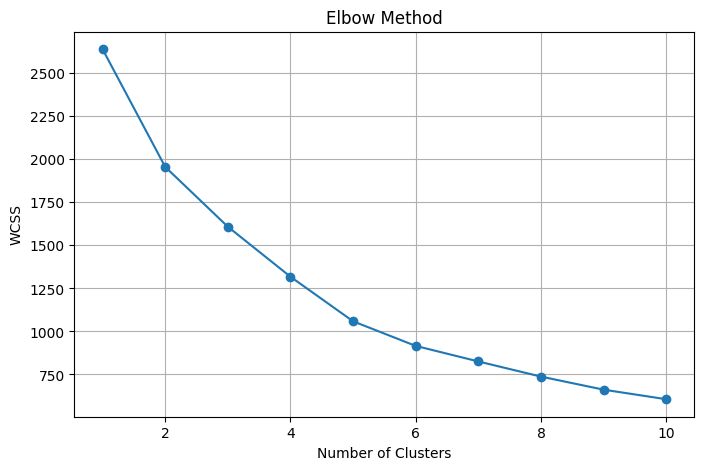

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,      # Change based on elbow graph
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

print(df.head())


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        1  
1        1776        1  
2        7844        1  
3        1788        1  
4        5185        1  


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

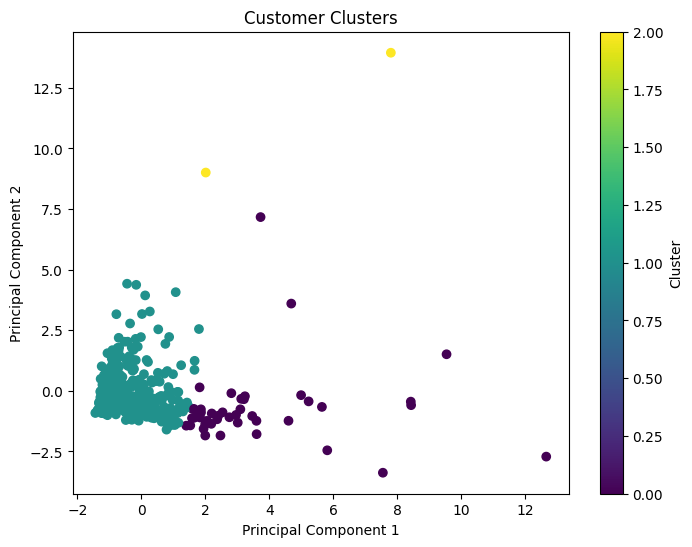

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
print("\nCluster-wise Mean Values:")
print(df.groupby('Cluster').mean())


Cluster-wise Mean Values:
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.977778  2.511111  10440.933333  19386.422222  28656.088889   
1        1.249364  2.547074  12062.913486   4115.099237   5534.966921   
2        1.000000  2.500000  34782.000000  30367.000000  16898.000000   

               Frozen  Detergents_Paper    Delicassen  
Cluster                                                
0         2190.244444      13327.800000   2374.200000  
1         2940.676845       1696.170483   1299.114504  
2        48701.500000        755.500000  26776.000000  
